In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import os

In [17]:
# 1. CẤU HÌNH
# Danh sách tên các model và tên file tương ứng
models_config = {
    'Linear Regression': 'LN.csv',
    'Random Forest': 'RF.csv',
    'XGBoost': 'XG.csv',
    'LightGBM': 'LGBM.csv',
    'LSTM (only Gold)': 'LSTM.csv' 
}
# Đường dẫn đến folder chứa file CSV kết quả
PRED_DIR = '../../results/predictions/'

In [18]:
# 2. HÀM ĐÁNH GIÁ HIỆU SUẤT
metrics_list = []
dfs = {} # Lưu data của từng model để vẽ

print("📊 Đang tổng hợp kết quả...")

for model_name, file_name in models_config.items():
    file_path = os.path.join(PRED_DIR, file_name)
    
    if os.path.exists(file_path):
        # Đọc dữ liệu
        df = pd.read_csv(file_path, parse_dates=['Datetime'])
        dfs[model_name] = df
        
        # Tính toán chỉ số
        y_true = df['Actual']
        y_pred = df['Predicted']
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Lưu vào list để tạo bảng so sánh
        metrics_list.append({
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2 Score': r2
        })
    else:
        print(f"⚠️ Không tìm thấy file: {file_name}")

📊 Đang tổng hợp kết quả...


In [19]:
# Tạo bảng tổng sắp (DataFrame)
metrics_df = pd.DataFrame(metrics_list)
# Sắp xếp theo MAE từ thấp đến cao (Càng thấp càng tốt)
metrics_df = metrics_df.sort_values(by='MAE', ascending=True)

print("\n🏆 BẢNG XẾP HẠNG HIỆU SUẤT:")
print(metrics_df)

# Lưu bảng này lại để dán vào báo cáo
metrics_df.to_csv('../../results/final_comparison_metrics.csv', index=False)


🏆 BẢNG XẾP HẠNG HIỆU SUẤT:
               Model        MAE       RMSE  R2 Score
0  Linear Regression   0.060944   0.680955  0.999870
4   LSTM (only Gold)   0.732100   1.220143  0.999581
3           LightGBM  44.496677  64.693745 -0.176638
2            XGBoost  44.964175  65.376684 -0.201625
1      Random Forest  46.198093  67.165871 -0.268281


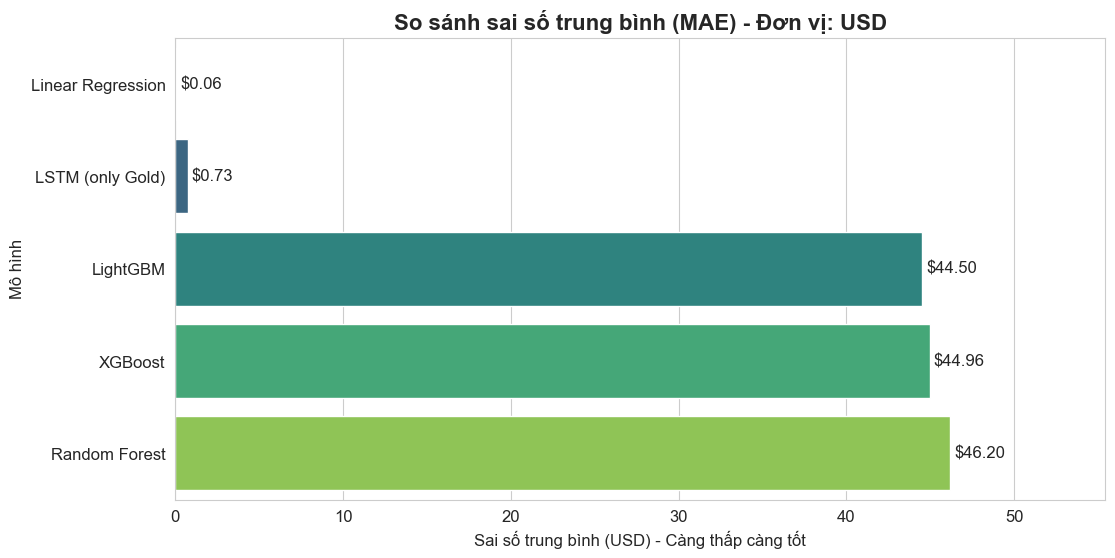

In [20]:
# ==============================================================================
# 3. TRỰC QUAN HÓA CHUYÊN NGHIỆP (Updated cho giá USD)
# ==============================================================================
import matplotlib.ticker as ticker

# SET UP GIAO DIỆN (Style)
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# ---------------------------------------------------------
# A. BIỂU ĐỒ CỘT: SO SÁNH MAE (Sai số trung bình)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=metrics_df, x='MAE', y='Model', palette='viridis', hue='Model', legend=False)

# Thêm số tiền cụ thể lên đầu mỗi cột
for i in ax.containers:
    ax.bar_label(i, fmt='$%.2f', padding=3) # Ví dụ: $12.50

plt.title('So sánh sai số trung bình (MAE) - Đơn vị: USD', fontsize=16, fontweight='bold')
plt.xlabel('Sai số trung bình (USD) - Càng thấp càng tốt')
plt.ylabel('Mô hình')
plt.xlim(0, metrics_df['MAE'].max() * 1.2) # Mở rộng lề phải để không bị che số
plt.show()

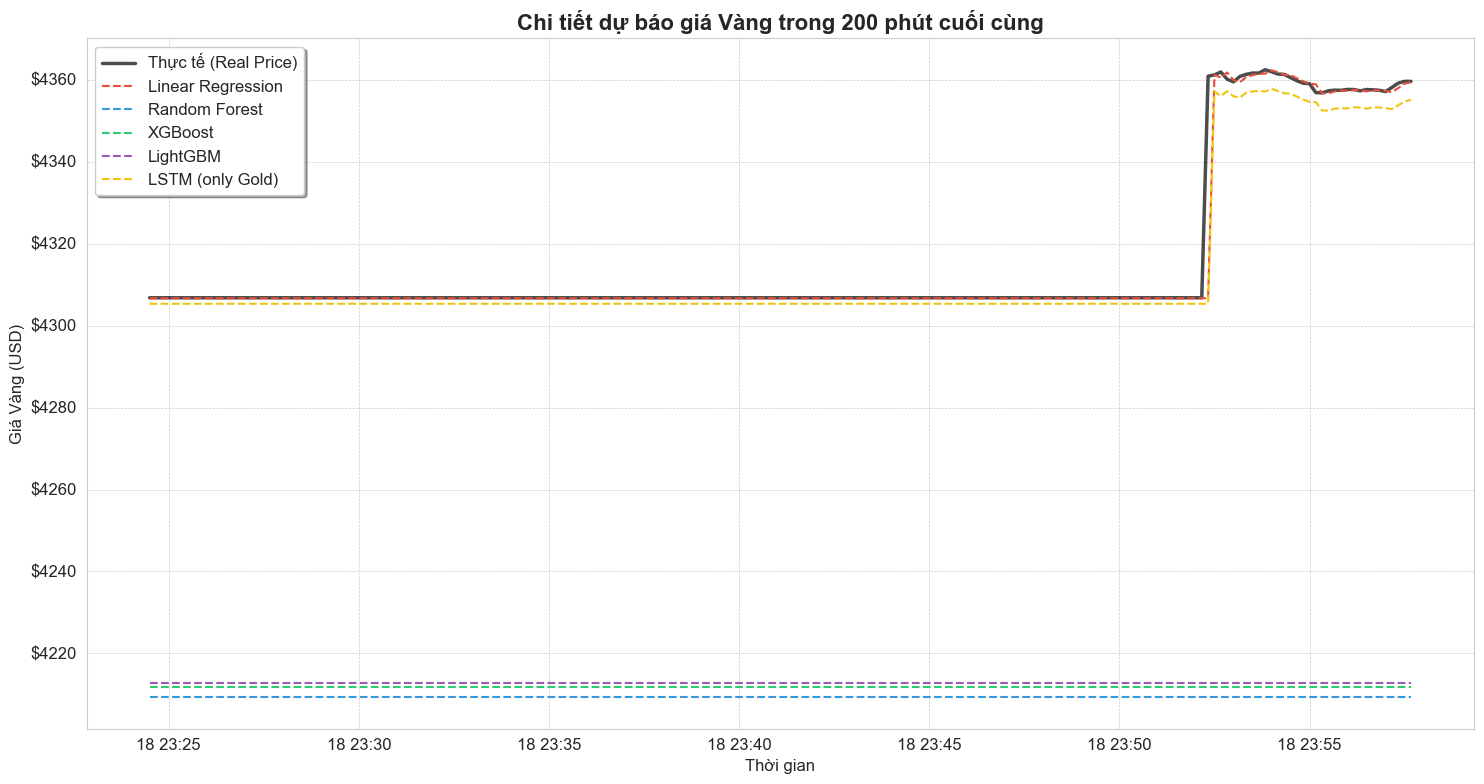

In [21]:
# ---------------------------------------------------------
# B. BIỂU ĐỒ ĐƯỜNG: DỰ BÁO VS THỰC TẾ (Zoom vào 200 điểm cuối)
# ---------------------------------------------------------
# Lý do: Vẽ cả chục nghìn điểm sẽ bị rối, chỉ cần vẽ đoạn cuối để thấy độ "bám"
plt.figure(figsize=(15, 8))

# Lấy 200 phút cuối cùng để vẽ cho rõ
n_points = 200
first_model = list(dfs.keys())[0]
time_index = dfs[first_model].iloc[-n_points:]['Datetime']
y_real = dfs[first_model].iloc[-n_points:]['Actual']

# Vẽ đường Thực tế (Nền)
plt.plot(time_index, y_real, label='Thực tế (Real Price)', color='black', linewidth=2.5, alpha=0.7)

# Vẽ đường Dự báo của các model
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f1c40f'] # Đỏ, Xanh, Lá, Tím, Vàng
markers = [None, None, None, None, None] 

for i, (name, df_full) in enumerate(dfs.items()):
    # Lấy đúng 200 điểm cuối tương ứng
    subset = df_full.iloc[-n_points:]
    plt.plot(subset['Datetime'], subset['Predicted'], 
             label=name, 
             color=colors[i % len(colors)], 
             linestyle='--', 
             linewidth=1.5)

# Định dạng trục Tung (Y-axis) thành tiền tệ ($)
formatter = ticker.FormatStrFormatter('$%.0f')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(f'Chi tiết dự báo giá Vàng trong {n_points} phút cuối cùng', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Giá Vàng (USD)')
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------------
# C. NHẬN XÉT TỰ ĐỘNG
# ---------------------------------------------------------
best_model = metrics_df.iloc[0]
worst_model = metrics_df.iloc[-1]

print(f"\n💡 NHẬN XÉT SƠ BỘ:")
print(f"- Mô hình tốt nhất là **{best_model['Model']}** với sai số trung bình chỉ **${best_model['MAE']:.2f}**.")
print(f"- Mô hình kém nhất là **{worst_model['Model']}** với sai số lên tới **${worst_model['MAE']:.2f}**.")
print(f"- Chênh lệch hiệu suất giữa tốt nhất và kém nhất là **${(worst_model['MAE'] - best_model['MAE']):.2f}**.")


💡 NHẬN XÉT SƠ BỘ:
- Mô hình tốt nhất là **Linear Regression** với sai số trung bình chỉ **$0.06**.
- Mô hình kém nhất là **Random Forest** với sai số lên tới **$46.20**.
- Chênh lệch hiệu suất giữa tốt nhất và kém nhất là **$46.14**.
